In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import seaborn as sns

In [5]:
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv("../data/raw_data/kenya (1).csv")

In [10]:
df["country"]="kenya"
df["date"]=pd.to_datetime(df["YEAR"]*1000+df["DOY"], format="%Y%j")
df["Month"]=df["date"].dt.month

In [11]:
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [12]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


The temperature distribution appears relatively balanced, with the mean and median remaining close to each other, suggesting that it is not strongly skewed in either direction. The standard deviation of T2M_MAX is between approximately 1.4 and 2.3, indicating relatively moderate variation in maximum temperatures. PRECTOTCORR has a mean of 1.4 mm/day and a median of 0.38 mm/day, showing a right-skewed distribution in which most days have relatively low precipitation while some days receive much higher rainfall. Although RH2M has a relatively high standard deviation of 9, its mean and median are still fairly close, suggesting that it is not strongly skewed. Wind speed also appears to be relatively evenly distributed throughout the year.


In [13]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
Month          0
dtype: int64

In [14]:
missing_percentage=df.isna().mean()*100

In [15]:
missing_percentage[missing_percentage>5]

Series([], dtype: float64)

In [16]:
cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

In [17]:
Z_score=(df[cols]-df[cols].mean())/df[cols].std()

In [19]:
outlier_rows=(Z_score.abs()>3).any(axis=1)

### Outlier Treatment

The identified outlier rows will be **retained** rather than dropped or capped. A z-score greater than 3 indicates that an observation is unusually far from the mean, but it does not necessarily mean that the observation is an error. Since this is climate data, extreme temperatures, rainfall, humidity, or wind speeds may represent genuine weather events and are relevant to climate analysis.

Dropping these observations could remove important extreme events from the dataset, while capping them would change their original values and potentially reduce the observed severity of extreme conditions. Therefore, the outliers are retained and flagged for further analysis rather than automatically treating them as errors.


In [ ]:
outlier_rows.sum()

np.int64(120)

In [22]:
row_missing_percentage = df.isna().mean(axis=1) * 100

In [23]:
df=df[row_missing_percentage<=30]

In [40]:
df.to_csv("../data/processed_data/kenya_clean.csv", index=False)

In [25]:
monthly_t2m = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

In [26]:
monthly_t2m["date"] = pd.to_datetime(
    monthly_t2m["YEAR"].astype(str) + "-" +
    monthly_t2m["Month"].astype(str) + "-01"
)

In [27]:
peak_tempMax = monthly_t2m.loc[monthly_t2m["T2M"].idxmax()]

In [28]:
peak_tempMin = monthly_t2m.loc[monthly_t2m["T2M"].idxmin()]

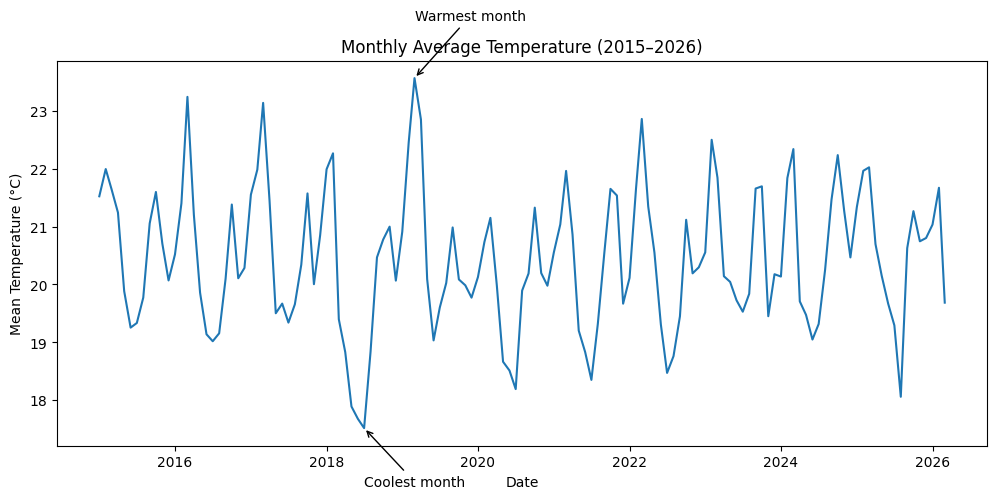

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_t2m["date"], monthly_t2m["T2M"])

# Warmest month
plt.annotate(
    "Warmest month",
    xy=(peak_tempMax["date"], peak_tempMax["T2M"]),
    xytext=(peak_tempMax["date"], peak_tempMax["T2M"] + 1),
    arrowprops=dict(arrowstyle="->")
)

# Coolest month
plt.annotate(
    "Coolest month",
    xy=(peak_tempMin["date"], peak_tempMin["T2M"]),
    xytext=(peak_tempMin["date"], peak_tempMin["T2M"] - 1),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Monthly Average Temperature (2015–2026)")

plt.show()

The warmest and coolest periods occur at different points within the same overall timeline, while the temperature repeatedly rises and falls throughout the years. This suggests that the temperature does not show a clear consistent increasing or decreasing trend. Instead, it shows fluctuations, with similar patterns of ups and downs occurring during different periods of the year.


In [30]:
monthly_prec=df.groupby(["Month"])["PRECTOTCORR"].sum().reset_index()

In [31]:
peak_rain = monthly_prec.loc[monthly_prec["PRECTOTCORR"].idxmax()]

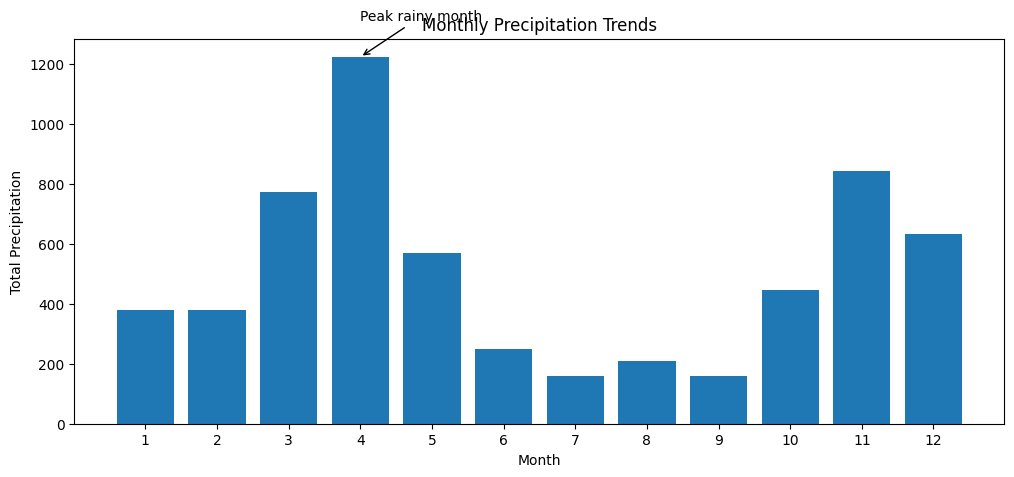

In [32]:
plt.figure(figsize=(12,5))
plt.bar(monthly_prec["Month"],monthly_prec["PRECTOTCORR"])
plt.annotate(
    "Peak rainy month",
    xy=(peak_rain["Month"], peak_rain["PRECTOTCORR"]),
    xytext=(peak_rain["Month"], peak_rain["PRECTOTCORR"] * 1.1),
    arrowprops=dict(arrowstyle="->")
)
plt.xlabel("Month")
plt.ylabel("Total Precipitation")
plt.title("Monthly Precipitation Trends")
plt.xticks(range(1, 13))
plt.show()

The graph shows that precipitation is relatively well distributed throughout the year. Although November and December have noticeably higher rainfall, the other months are not completely dry; they simply receive less precipitation. Overall, the rainfall pattern does not appear to be concentrated in only a few rainy months, but instead shows precipitation throughout the year with some seasonal variation.


In [33]:
number=df.select_dtypes(include="number")

In [34]:
correlation=number.corr()

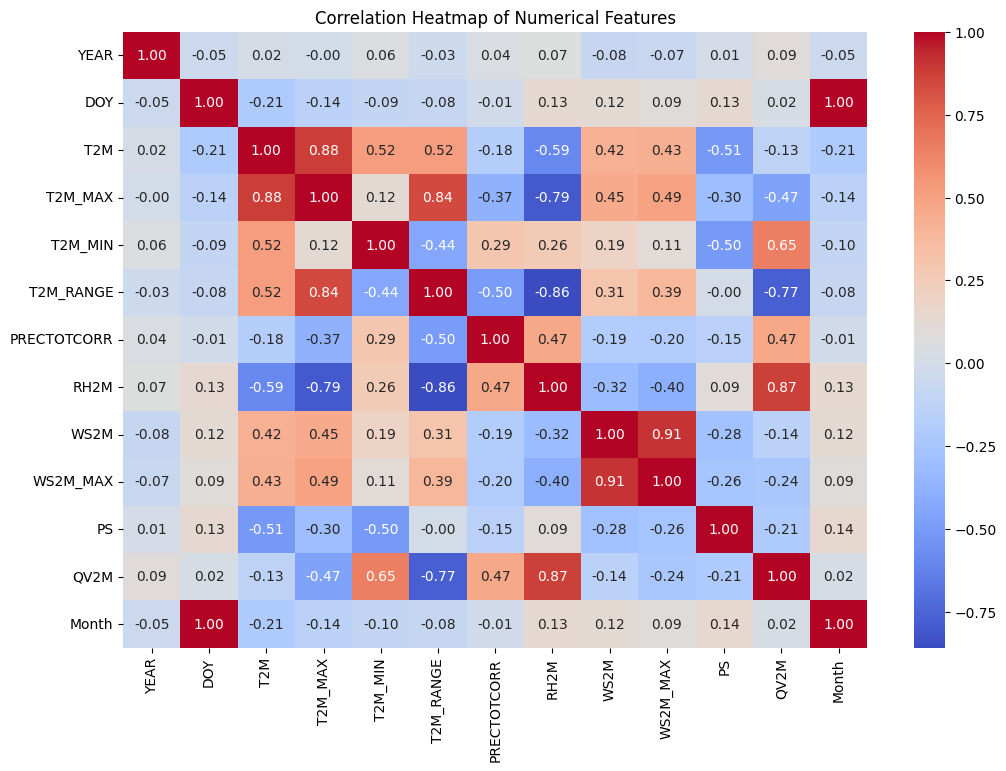

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The correlation heatmap shows a strong positive relationship between QV2M and RH2M, with a correlation of **0.87**. This indicates that higher specific humidity is generally associated with higher relative humidity.

QV2M and T2M_RANGE show a strong negative relationship, with a correlation of **-0.77**, meaning that higher specific humidity is generally associated with a smaller daily temperature range.

T2M_RANGE and RH2M also show a strong negative correlation of **-0.86**. Together, these relationships show a strong association between humidity variables and daily temperature range.


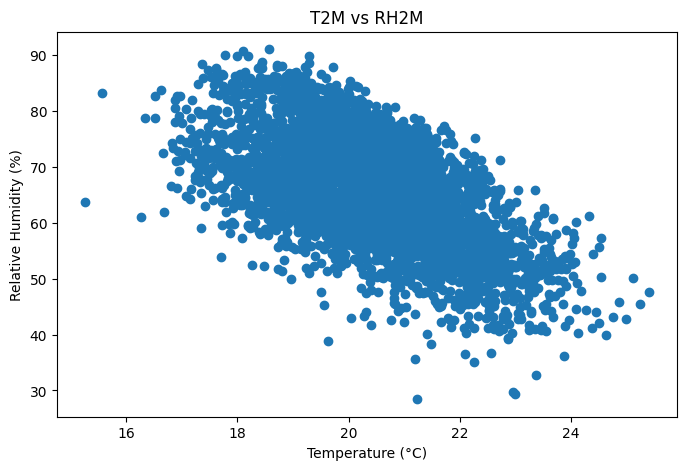

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")

plt.show()

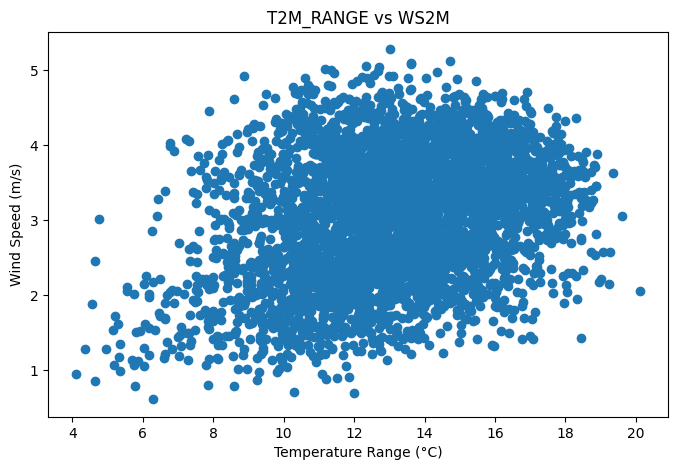

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.title("T2M_RANGE vs WS2M")
plt.show()

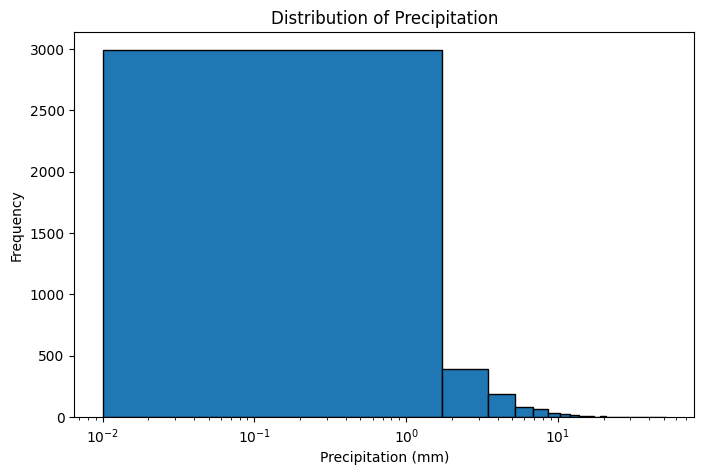

In [38]:
rain=df.loc[df["PRECTOTCORR"]>0, "PRECTOTCORR"]
plt.figure(figsize=(8,5))
plt.hist(rain, bins=30, edgecolor="black")
plt.xscale("log")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Precipitation")
plt.show()

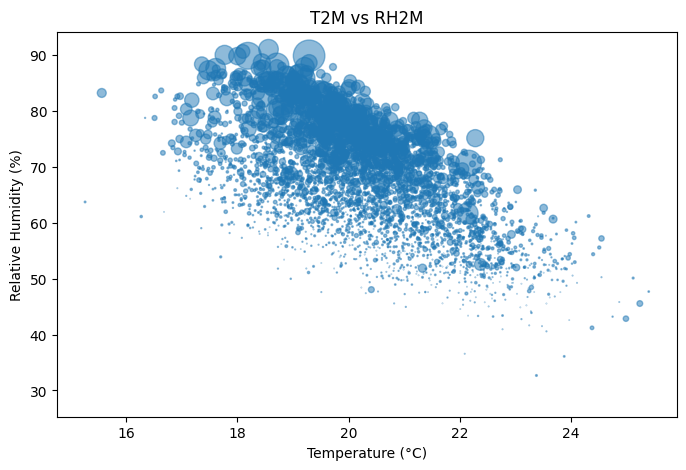

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"],df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5 )
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")
plt.show()